# Entrainement Et Benchmark Des Modeles AQUA-ATMOS

Ce notebook compare plusieurs modeles sur les memes splits et les memes metriques, sans fuite de pretraitement.


## 1. Chargement Des Splits

**Objectif**
Charger les jeux `train`, `validation` et `test` prepares au notebook precedent.

**Resultat attendu**
Disposer de trois jeux alignes et prets pour un benchmark reproductible.


In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd

try:
    from IPython.display import display
except Exception:
    def display(value):
        print(value)

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "processed"

train_df = pd.read_csv(DATA_DIR / "train_split.csv")
valid_df = pd.read_csv(DATA_DIR / "validation_split.csv")
test_df = pd.read_csv(DATA_DIR / "test_split.csv")

train_df.shape, valid_df.shape, test_df.shape


## 2. Definition Des Features Et Des Cibles

**Objectif**
Declarer explicitement les colonnes d'entree et les cibles du benchmark.

**Resultat attendu**
Eviter toute ambiguite entre les modeles compares.


In [ ]:
feature_columns = [
    "city_id",
    "hour",
    "temp_air_c",
    "hr_pct",
    "solar_wm2",
    "pv_voltage",
    "temp_collector_c",
    "temp_cond_c",
    "delta_hr_sorbent",
    "reservoir_level_pct",
    "soc_battery_pct",
    "dew_point_c",
    "humidity_ratio_gkg",
    "hour_sin",
    "hour_cos",
    "day_sin",
    "day_cos",
    "thermal_lift_c",
    "collector_gain_c",
    "is_daylight",
    "high_humidity_flag",
    "battery_stress_flag",
    "reservoir_high_flag",
]

target_columns = [
    "vcrc_state",
    "sorbent_mode_label",
    "heater_on_label",
    "sorbent_saturated_label",
]

categorical_features = ["city_id"]
numeric_features = [column for column in feature_columns if column not in categorical_features]

pd.DataFrame(
    {
        "feature_columns": pd.Series(feature_columns),
        "target_columns": pd.Series(target_columns),
    }
)


## 3. Baselines Et Pipelines

**Objectif**
Definir un ensemble minimal mais serieux de modeles a comparer.

**Resultat attendu**
Avoir des pipelines homogenes et reutilisables pour chaque cible.


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


def make_preprocessor(scale_numeric: bool) -> ColumnTransformer:
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore")),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("numeric", Pipeline(steps=numeric_steps), numeric_features),
            ("categorical", categorical_transformer, categorical_features),
        ]
    )


model_factories = {
    "dummy_most_frequent": lambda: DummyClassifier(strategy="most_frequent"),
    "logistic_regression": lambda: LogisticRegression(max_iter=2000, class_weight="balanced"),
    "random_forest": lambda: RandomForestClassifier(
        n_estimators=120,
        max_depth=8,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced_subsample",
    ),
    "hist_gradient_boosting": lambda: HistGradientBoostingClassifier(
        learning_rate=0.08,
        max_depth=6,
        max_iter=120,
        random_state=42,
    ),
}


def make_pipeline(model_name: str) -> Pipeline:
    estimator = model_factories[model_name]()
    scale_numeric = model_name == "logistic_regression"
    return Pipeline(
        steps=[
            ("preprocessor", make_preprocessor(scale_numeric=scale_numeric)),
            ("model", estimator),
        ]
    )


## 4. Equilibre Des Cibles

**Objectif**
Verifier s'il y a assez de cas positifs et si certaines classes sont trop rares.

**Resultat attendu**
Voir rapidement si un bon score global peut cacher un desequilibre.


In [ ]:
balance_rows = []
for split_name, frame in [("train", train_df), ("validation", valid_df), ("test", test_df)]:
    for target in target_columns:
        balance_rows.append(
            {
                "split": split_name,
                "target": target,
                "distribution": frame[target].value_counts(normalize=True).sort_index().to_dict(),
            }
        )

balance_df = pd.DataFrame(balance_rows)
display(balance_df)


## 5. Metriques Et Cas Extemes

**Objectif**
Utiliser les memes metriques sur chaque cible et suivre separement les cas difficiles.

**Resultat attendu**
Pouvoir comparer les modeles sans se limiter a l'accuracy globale.


In [ ]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, precision_score, recall_score


X_train = train_df[feature_columns].copy()
X_valid = valid_df[feature_columns].copy()
X_test = test_df[feature_columns].copy()

y_train = {target: train_df[target].copy() for target in target_columns}
y_valid = {target: valid_df[target].copy() for target in target_columns}
y_test = {target: test_df[target].copy() for target in target_columns}


train_extreme_thresholds = {
    "temp_air_c_low": train_df["temp_air_c"].quantile(0.01),
    "temp_air_c_high": train_df["temp_air_c"].quantile(0.99),
    "hr_pct_high": train_df["hr_pct"].quantile(0.99),
    "solar_wm2_low_nonzero": train_df.loc[train_df["solar_wm2"] > 0, "solar_wm2"].quantile(0.05),
    "soc_battery_pct_low": train_df["soc_battery_pct"].quantile(0.05),
}


def build_extreme_mask(frame: pd.DataFrame) -> pd.Series:
    return (
        (frame["temp_air_c"] <= train_extreme_thresholds["temp_air_c_low"])
        | (frame["temp_air_c"] >= train_extreme_thresholds["temp_air_c_high"])
        | (frame["hr_pct"] >= train_extreme_thresholds["hr_pct_high"])
        | ((frame["solar_wm2"] > 0) & (frame["solar_wm2"] <= train_extreme_thresholds["solar_wm2_low_nonzero"]))
        | (frame["soc_battery_pct"] <= train_extreme_thresholds["soc_battery_pct_low"])
    )


extreme_masks = {
    "validation": build_extreme_mask(valid_df),
    "test": build_extreme_mask(test_df),
}


def classification_metrics(y_true: pd.Series, y_pred: np.ndarray) -> dict[str, float]:
    if len(pd.Series(y_true).unique()) == 1:
        balanced_accuracy = float((pd.Series(y_true).to_numpy() == y_pred).mean())
    else:
        balanced_accuracy = balanced_accuracy_score(y_true, y_pred)

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy,
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }


## 6. Benchmark Sur Validation

**Objectif**
Entrainer tous les modeles sur le train et les comparer sur validation.

**Resultat attendu**
Identifier un meilleur modele par cible avec un tableau clair des scores.


In [14]:
validation_rows = []
fitted_models = {}

for target_name in target_columns:
    fitted_models[target_name] = {}
    for model_name in model_factories:
        pipeline = make_pipeline(model_name)
        pipeline.fit(X_train, y_train[target_name])

        y_valid_pred = pipeline.predict(X_valid)
        metrics = classification_metrics(y_valid[target_name], y_valid_pred)

        extreme_mask = extreme_masks["validation"]
        extreme_metrics = classification_metrics(
            y_valid[target_name].loc[extreme_mask],
            y_valid_pred[extreme_mask.to_numpy()],
        )

        validation_rows.append(
            {
                "target": target_name,
                "model": model_name,
                **{f"validation_{name}": value for name, value in metrics.items()},
                **{f"validation_extreme_{name}": value for name, value in extreme_metrics.items()},
            }
        )
        fitted_models[target_name][model_name] = pipeline

validation_results = pd.DataFrame(validation_rows).sort_values(
    ["target", "validation_f1_macro", "validation_balanced_accuracy"],
    ascending=[True, False, False],
)

display(validation_results)


,target,model,validation_accuracy,validation_balanced_accuracy,validation_precision_macro,validation_recall_macro,validation_f1_macro,validation_extreme_accuracy,validation_extreme_balanced_accuracy,validation_extreme_precision_macro,validation_extreme_recall_macro,validation_extreme_f1_macro
11,heater_on_label,hist_gradient_boosting,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
8,heater_on_label,dummy_most_frequent,0.999242,0.500000,0.499621,0.500000,0.499811,1.000000,1.000000,1.000000,1.000000,1.000000
9,heater_on_label,logistic_regression,0.999242,0.500000,0.499621,0.500000,0.499811,1.000000,1.000000,1.000000,1.000000,1.000000
10,heater_on_label,random_forest,0.999242,0.500000,0.499621,0.500000,0.499811,1.000000,1.000000,1.000000,1.000000,1.000000
7,sorbent_mode_label,hist_gradient_boosting,0.999242,0.999716,0.996997,0.999716,0.998350,0.995671,0.998291,0.990741,0.998291,0.994448
6,sorbent_mode_label,random_forest,0.998485,0.987710,0.996686,0.987710,0.992133,1.000000,1.000000,1.000000,1.000000,1.000000
5,sorbent_mode_label,logistic_regression,0.853788,0.727246,0.674306,0.727246,0.661443,0.761905,0.574359,0.462072,0.574359,0.467104
4,sorbent_mode_label,dummy_most_frequent,0.889394,0.333333,0.296465,0.333333,0.313820,0.844156,0.333333,0.281385,0.333333,0.305164
14,sorbent_saturated_label,random_forest,0.999242,0.996124,0.999581,0.996124,0.997845,1.000000,1.000000,1.000000,1.000000,1.000000
15,sorbent_saturated_label,hist_gradient_boosting,0.998485,0.995704,0.995704,0.995704,0.995704,0.995671,0.997436,0.986486,0.997436,0.991865


## 7. Selection Du Meilleur Modele Par Cible

**Objectif**
Choisir un seul modele par cible sur la base de la validation.

**Resultat attendu**
Avoir une selection explicite avant toute evaluation sur test.


In [15]:
best_models = (
    validation_results.sort_values(
        ["target", "validation_f1_macro", "validation_balanced_accuracy"],
        ascending=[True, False, False],
    )
    .groupby("target", as_index=False)
    .first()
    .rename(columns={"model": "selected_model"})
)

display(best_models[["target", "selected_model", "validation_f1_macro", "validation_balanced_accuracy"]])


,target,selected_model,validation_f1_macro,validation_balanced_accuracy
0,heater_on_label,hist_gradient_boosting,1.000000,1.000000
1,sorbent_mode_label,hist_gradient_boosting,0.998350,0.999716
2,sorbent_saturated_label,random_forest,0.997845,0.996124
3,vcrc_state,hist_gradient_boosting,0.998080,0.999574


## 8. Evaluation Finale Sur Test

**Objectif**
Evaluer uniquement les modeles retenus sur le jeu de test.

**Resultat attendu**
Obtenir une estimation finale non biaisee des performances.


In [16]:
test_rows = []

for row in best_models.itertuples(index=False):
    target_name = row.target
    model_name = row.selected_model
    pipeline = fitted_models[target_name][model_name]

    y_test_pred = pipeline.predict(X_test)
    metrics = classification_metrics(y_test[target_name], y_test_pred)

    extreme_mask = extreme_masks["test"]
    extreme_metrics = classification_metrics(
        y_test[target_name].loc[extreme_mask],
        y_test_pred[extreme_mask.to_numpy()],
    )

    test_rows.append(
        {
            "target": target_name,
            "selected_model": model_name,
            **{f"test_{name}": value for name, value in metrics.items()},
            **{f"test_extreme_{name}": value for name, value in extreme_metrics.items()},
        }
    )

test_results = pd.DataFrame(test_rows).sort_values("target")
display(test_results)


,target,selected_model,test_accuracy,test_balanced_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_extreme_accuracy,test_extreme_balanced_accuracy,test_extreme_precision_macro,test_extreme_recall_macro,test_extreme_f1_macro
0,heater_on_label,hist_gradient_boosting,0.996970,0.957187,0.892474,0.957187,0.922312,1.0,1.0,1.0,1.0,1.0
1,sorbent_mode_label,hist_gradient_boosting,0.980303,0.962624,0.935244,0.962624,0.947659,1.0,1.0,1.0,1.0,1.0
2,sorbent_saturated_label,random_forest,0.996212,0.985207,0.997837,0.985207,0.991409,1.0,1.0,1.0,1.0,1.0
3,vcrc_state,hist_gradient_boosting,0.983333,0.965867,0.961347,0.965867,0.963592,1.0,1.0,1.0,1.0,1.0


## 9. Matrices De Confusion Separees

**Objectif**
Qualifier les erreurs du meilleur modele sur chaque cible.

**Resultat attendu**
Voir clairement quelles classes sont confondues, avec une image par cible.


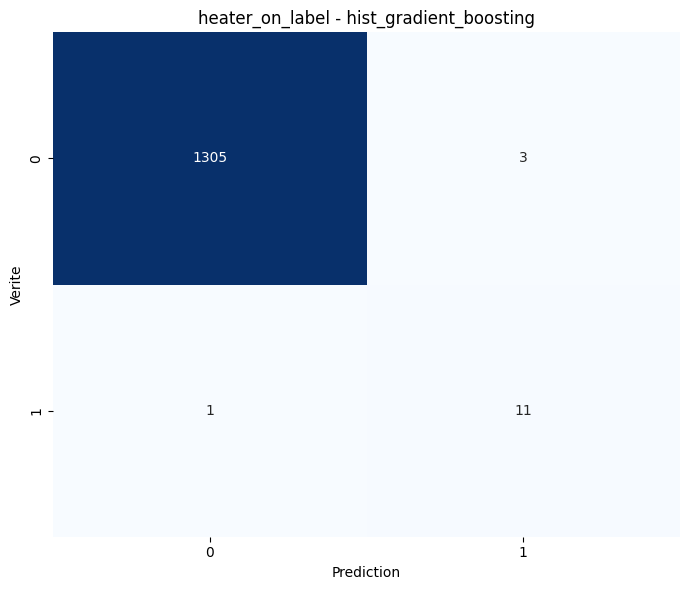

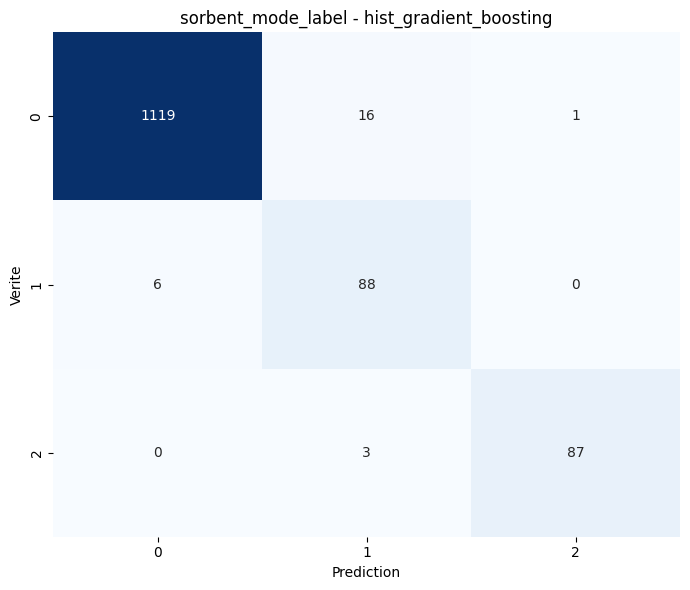

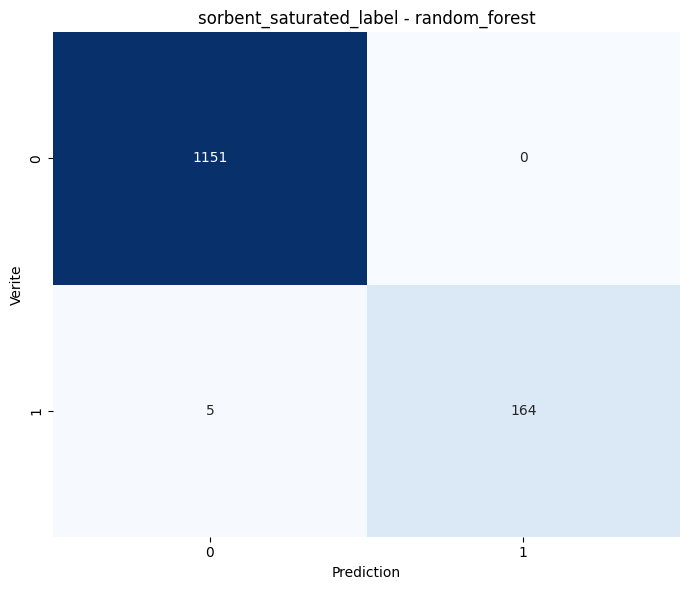

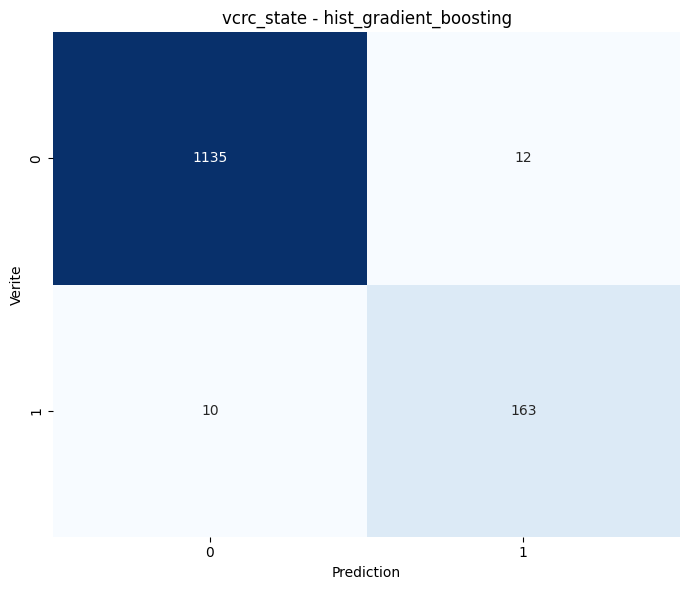

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

for row in best_models.itertuples(index=False):
    target_name = row.target
    model_name = row.selected_model
    pipeline = fitted_models[target_name][model_name]
    y_pred = pipeline.predict(X_test)

    labels = sorted(y_test[target_name].unique().tolist())
    matrix = confusion_matrix(y_test[target_name], y_pred, labels=labels)
    plt.figure(figsize=(7, 6))
    ax = plt.gca()
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(f"{target_name} - {model_name}")
    ax.set_xlabel("Prediction")
    ax.set_ylabel("Verite")
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    plt.tight_layout()
    plt.show()


## 10. Lecture Des Performances

**Objectif**
Afficher les performances de facon plus lisible et plus complete que par un cout agrege.

**Resultat attendu**
Comparer les modeles par cible et par metrique, sans melanger artificiellement les scores.


,target,model,validation_accuracy,validation_balanced_accuracy,validation_precision_macro,validation_recall_macro,validation_f1_macro,validation_extreme_f1_macro
11,heater_on_label,hist_gradient_boosting,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
8,heater_on_label,dummy_most_frequent,0.999242,0.500000,0.499621,0.500000,0.499811,1.000000
9,heater_on_label,logistic_regression,0.999242,0.500000,0.499621,0.500000,0.499811,1.000000
10,heater_on_label,random_forest,0.999242,0.500000,0.499621,0.500000,0.499811,1.000000
7,sorbent_mode_label,hist_gradient_boosting,0.999242,0.999716,0.996997,0.999716,0.998350,0.994448
6,sorbent_mode_label,random_forest,0.998485,0.987710,0.996686,0.987710,0.992133,1.000000
5,sorbent_mode_label,logistic_regression,0.853788,0.727246,0.674306,0.727246,0.661443,0.467104
4,sorbent_mode_label,dummy_most_frequent,0.889394,0.333333,0.296465,0.333333,0.313820,0.305164
14,sorbent_saturated_label,random_forest,0.999242,0.996124,0.999581,0.996124,0.997845,1.000000
15,sorbent_saturated_label,hist_gradient_boosting,0.998485,0.995704,0.995704,0.995704,0.995704,0.991865


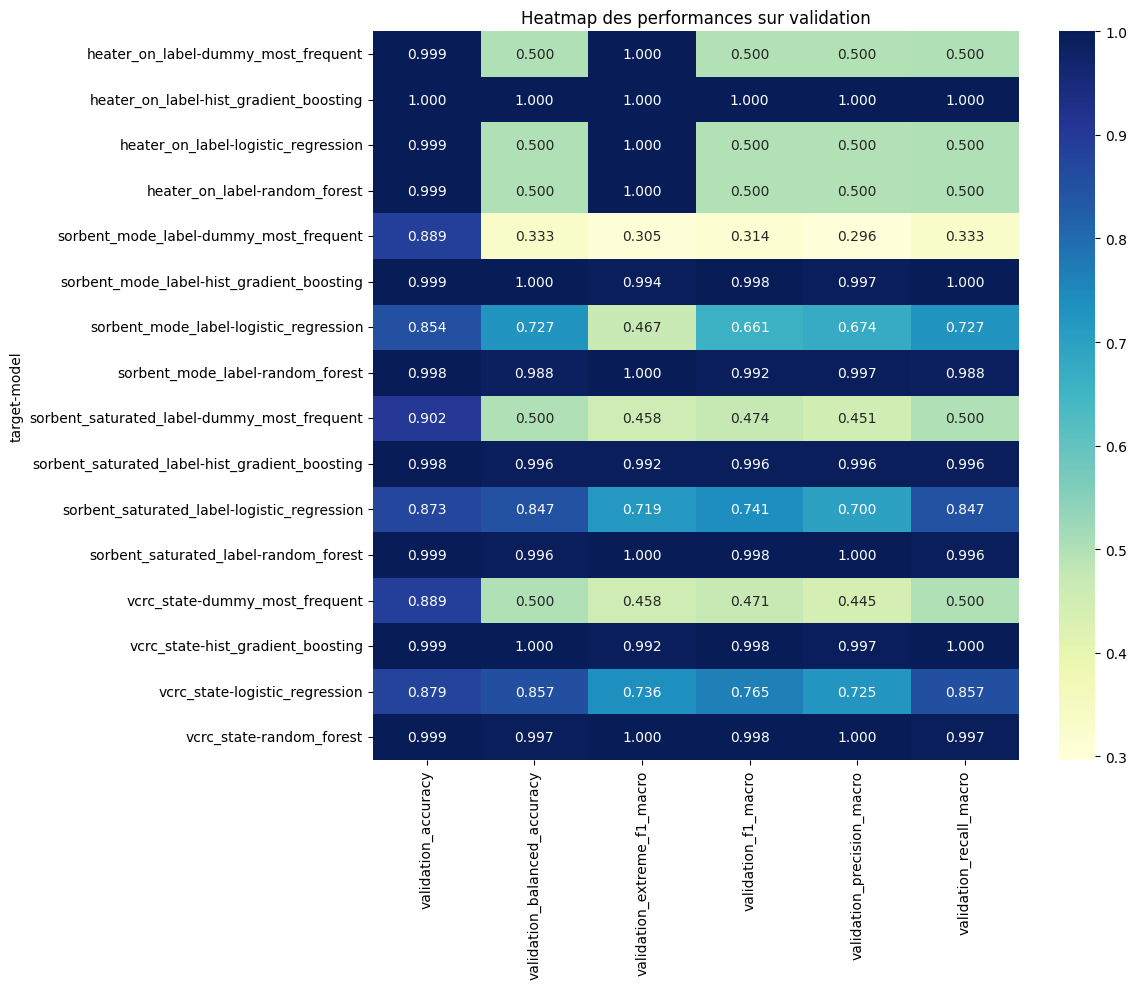

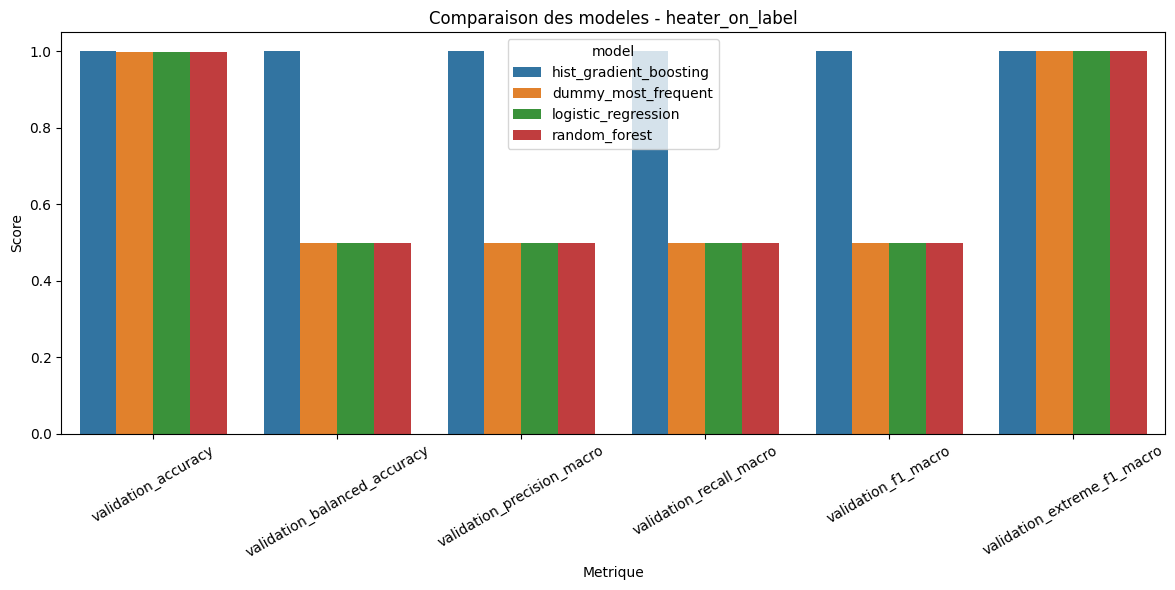

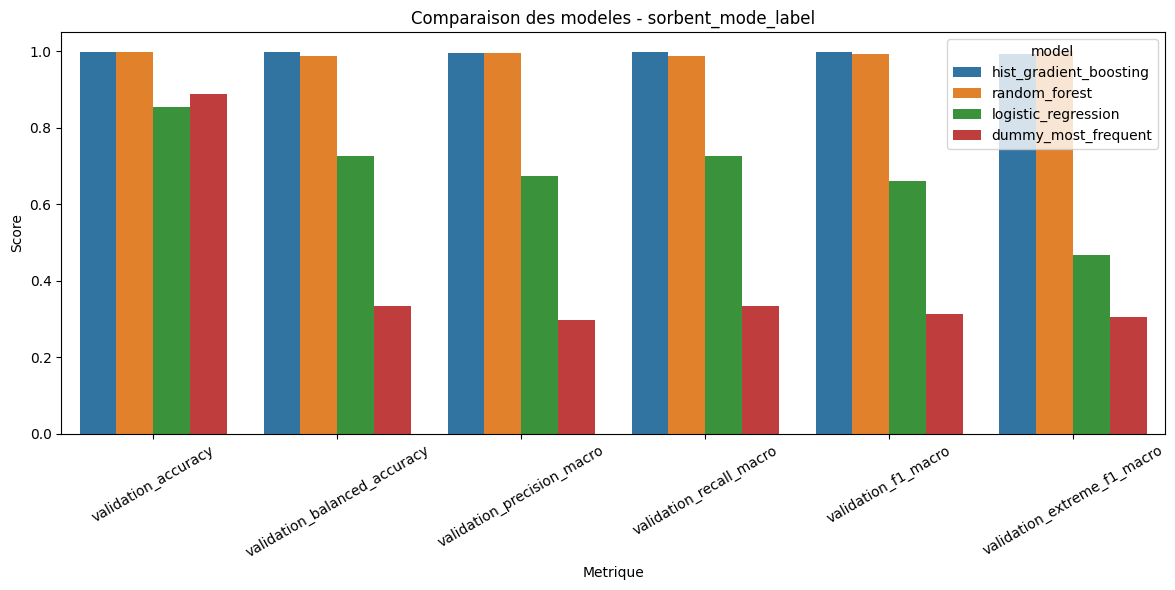

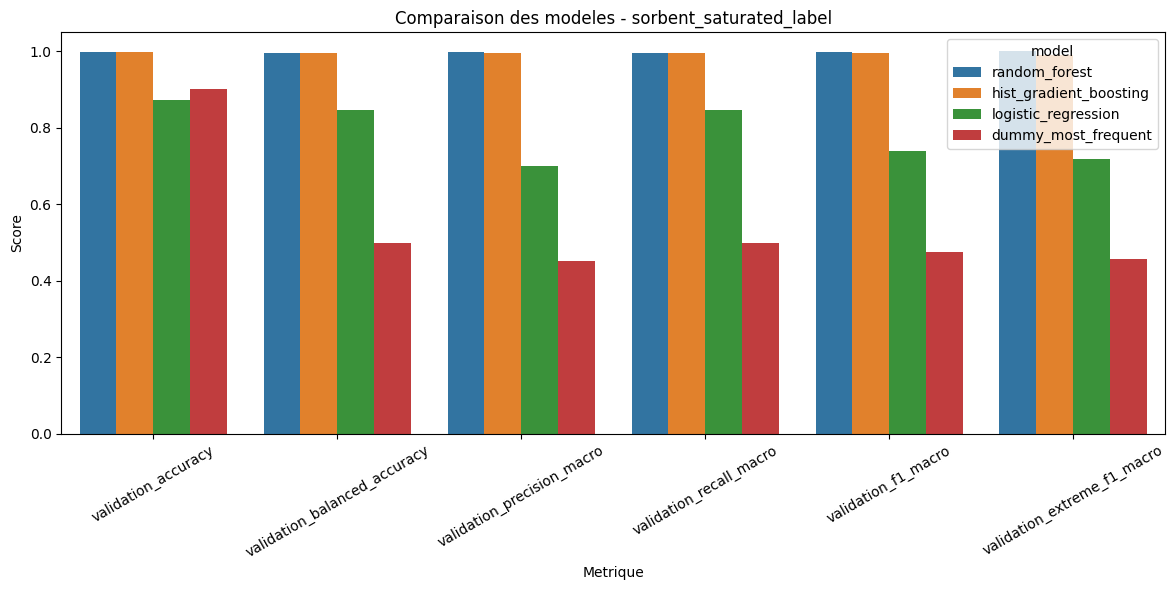

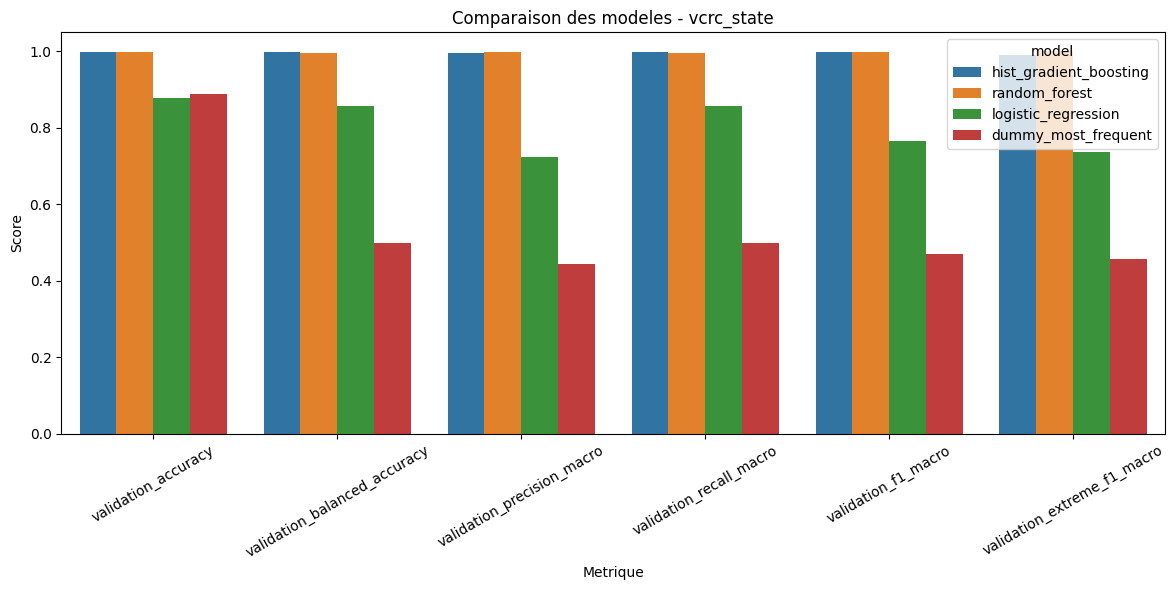

In [18]:
validation_overview = validation_results[
    [
        "target",
        "model",
        "validation_accuracy",
        "validation_balanced_accuracy",
        "validation_precision_macro",
        "validation_recall_macro",
        "validation_f1_macro",
        "validation_extreme_f1_macro",
    ]
].copy()
display(validation_overview.sort_values(["target", "validation_f1_macro"], ascending=[True, False]))

heatmap_frame = validation_overview.pivot_table(
    index=["target", "model"],
    values=[
        "validation_accuracy",
        "validation_balanced_accuracy",
        "validation_precision_macro",
        "validation_recall_macro",
        "validation_f1_macro",
        "validation_extreme_f1_macro",
    ],
)

plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_frame, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("Heatmap des performances sur validation")
plt.tight_layout()
plt.show()

for target_name, target_frame in validation_overview.groupby("target"):
    melted = target_frame.melt(
        id_vars=["target", "model"],
        value_vars=[
            "validation_accuracy",
            "validation_balanced_accuracy",
            "validation_precision_macro",
            "validation_recall_macro",
            "validation_f1_macro",
            "validation_extreme_f1_macro",
        ],
        var_name="metric",
        value_name="score",
    )

    plt.figure(figsize=(12, 6))
    sns.barplot(data=melted, x="metric", y="score", hue="model")
    plt.title(f"Comparaison des modeles - {target_name}")
    plt.xlabel("Metrique")
    plt.ylabel("Score")
    plt.xticks(rotation=30)
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.show()


## 11. Frontiere De Decision 2D

**Objectif**
Afficher une vraie frontiere de decision lisible sur deux variables metier.

**Resultat attendu**
Voir comment les classes sont separees sur un plan interpretable.


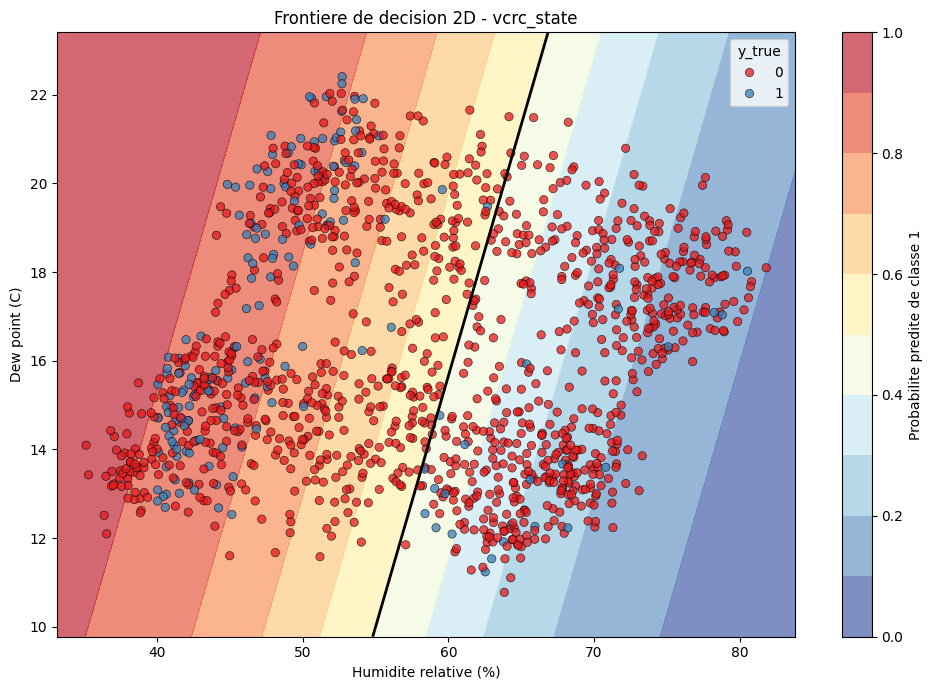

Note: la frontiere 2D ci-dessus est une vue interpretable avec un modele lineaire sur deux variables. Un RandomForest ou un Gradient Boosting n'a pas un hyperplan unique simple a tracer.


In [19]:
reference_target = "vcrc_state"
decision_features = ["hr_pct", "dew_point_c"]

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

boundary_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced")),
    ]
)
boundary_model.fit(train_df[decision_features], y_train[reference_target])

x_min, x_max = X_test["hr_pct"].min() - 2, X_test["hr_pct"].max() + 2
y_min, y_max = X_test["dew_point_c"].min() - 1, X_test["dew_point_c"].max() + 1
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 250),
    np.linspace(y_min, y_max, 250),
)
grid = pd.DataFrame({"hr_pct": xx.ravel(), "dew_point_c": yy.ravel()})
zz = boundary_model.predict_proba(grid)[:, 1].reshape(xx.shape)

plot_df = X_test[decision_features].copy()
plot_df["y_true"] = y_test[reference_target].to_numpy()

plt.figure(figsize=(10, 7))
contour = plt.contourf(xx, yy, zz, levels=np.linspace(0, 1, 11), cmap="RdYlBu_r", alpha=0.65)
plt.contour(xx, yy, zz, levels=[0.5], colors="black", linewidths=2)
sns.scatterplot(
    data=plot_df,
    x="hr_pct",
    y="dew_point_c",
    hue="y_true",
    palette="Set1",
    edgecolor="black",
    alpha=0.75,
)
plt.title(f"Frontiere de decision 2D - {reference_target}")
plt.xlabel("Humidite relative (%)")
plt.ylabel("Dew point (C)")
plt.colorbar(contour, label="Probabilite predite de classe 1")
plt.tight_layout()
plt.show()

print(
    "Note: la frontiere 2D ci-dessus est une vue interpretable avec un modele lineaire sur deux variables. "
    "Un RandomForest ou un Gradient Boosting n'a pas un hyperplan unique simple a tracer."
)


## 12. Vue 3D Des Donnees

**Objectif**
Garder une vue 3D descriptive des donnees autour de la cible de reference.

**Resultat attendu**
Voir comment les points se distribuent dans l'espace metier.


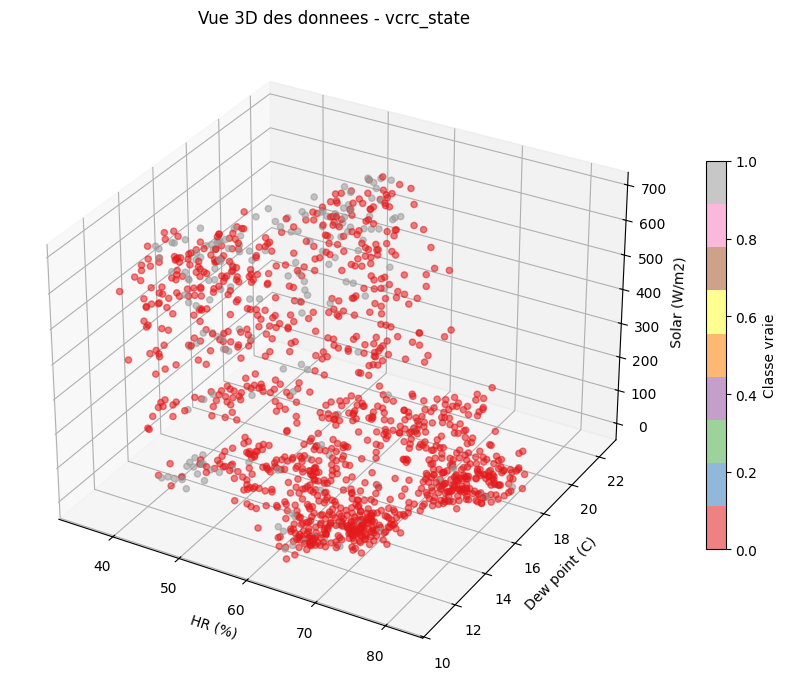

In [20]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

plot_df_3d = X_test[["hr_pct", "dew_point_c", "solar_wm2"]].copy()
plot_df_3d["y_true"] = y_test[reference_target].to_numpy()

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
scatter = ax.scatter(
    plot_df_3d["hr_pct"],
    plot_df_3d["dew_point_c"],
    plot_df_3d["solar_wm2"],
    c=plot_df_3d["y_true"],
    cmap="Set1",
    alpha=0.55,
)
ax.set_title(f"Vue 3D des donnees - {reference_target}")
ax.set_xlabel("HR (%)")
ax.set_ylabel("Dew point (C)")
ax.set_zlabel("Solar (W/m2)")
fig.colorbar(scatter, ax=ax, shrink=0.6, label="Classe vraie")
plt.tight_layout()
plt.show()


## 13. Resume Final

**Objectif**
Resumer les decisions a retenir pour la suite du projet.

**Resultat attendu**
Produire une table courte pour guider l'industrialisation du meilleur pipeline, avec une note sur le split.


In [21]:
split_note = (
    "Le split temporel evite la fuite du futur, mais peut cacher certains regimes si train, validation "
    "et test ne couvrent pas les memes saisons ou cas rares."
)

final_summary = best_models.merge(test_results, on="target", how="left")
final_summary = (
    final_summary[
        [
            "target",
            "selected_model_x",
            "validation_f1_macro",
            "validation_balanced_accuracy",
            "test_f1_macro",
            "test_balanced_accuracy",
            "test_extreme_f1_macro",
            "test_extreme_balanced_accuracy",
        ]
    ]
    .rename(columns={"selected_model_x": "selected_model"})
    .sort_values("target")
)
display(final_summary)
print(split_note)


,target,selected_model,validation_f1_macro,validation_balanced_accuracy,test_f1_macro,test_balanced_accuracy,test_extreme_f1_macro,test_extreme_balanced_accuracy
0,heater_on_label,hist_gradient_boosting,1.000000,1.000000,0.922312,0.957187,1.0,1.0
1,sorbent_mode_label,hist_gradient_boosting,0.998350,0.999716,0.947659,0.962624,1.0,1.0
2,sorbent_saturated_label,random_forest,0.997845,0.996124,0.991409,0.985207,1.0,1.0
3,vcrc_state,hist_gradient_boosting,0.998080,0.999574,0.963592,0.965867,1.0,1.0


Le split temporel evite la fuite du futur, mais peut cacher certains regimes si train, validation et test ne couvrent pas les memes saisons ou cas rares.
